# EDA и бинарная классификация на датасете «Титаник»
**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic  
**Выполнил:** Команич Роман Маркович  

**Группа:** АСОиУб-23-2  
**Преподаватель:** Спирин Игорь Сергеевич  
**Ссылка на репозиторий:** https://github.com/username/ml-course-komanich  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-09-29  

## Введение

### Какую задачу решаем?

Мы решаем задачу **бинарной классификации**, суть котором в том, чтобы предсказать, выжил ли пассажир «Титаника» в результате крушения 15 апреля 1912 года. Целевая переменная `Survived` принимает два значения:
- **0** — пассажир не выжил
- **1** — пассажир выжил


### Что такое ML-проект?

**ML-проект** — это проект по созданию и внедрению модели машинного обучения для решения конкретной задачи на основе данных.

**Жизненный цикл** ML‑проекта начинается со сбора и тщательной подготовки данных, включая разведочный анализ, обработку и создание новых признаков. Затем модель обучают, оценивают её качество и интерпретируют результаты, чтобы убедиться в надёжности выводов. На финальном этапе модель внедряют в работу и используют для предсказаний на новых данных.

Каждый этап влияет на итоговое качество модели, и пропуск любого из них может привести к ошибкам.

### Почему это классификация, а не регрессия?

**Регрессия** предсказывает **непрерывную величину**. Результат — любое число из диапазона.

**Классификация** предсказывает **дискретную метку класса**. Результат — одно из ограниченного набора значений.

В нашей задаче ответ на вопрос «выжил ли пассажир?» — это **дискретная метка**, то есть принимает значение 0 или 1, поэтому это **классификация**.

### Какая метрика важнее в этой задаче?

Для задачи «Титаник» **accuracy — плохая метрика**, потому что классы несбалансированы:

- Не выжило: **61.6%**
- Выжило: **38.4%**

Модель, которая **всегда предсказывает «не выжил»**, получит **accuracy = 61.6%**, ничего не выучив. Поэтому смотреть надо на другие метрики.

- **Precision** показывает, какая доля из предсказанных «выживших» действительно выжила. Высокая precision означает, что модель редко ошибается, когда говорит «выживет».

- **Recall** показывает, какую долю реально выживших пассажиров модель смогла найти. Высокий recall означает, что модель редко пропускает выживших.

- **F1-score** — это гармоническое среднее precision и recall. Он балансирует обе метрики: если одна из них низкая, F1 тоже будет низким.

- **ROC-AUC** — площадь под ROC-кривой. Она показывает, насколько хорошо модель разделяет два класса, и **не зависит от порога классификации**. Значение 0.5 соответствует случайному угадыванию, 1.0 — идеальной модели.

**Итог:** основной метрикой выбираем **ROC-AUC** — она устойчива к дисбалансу классов и показывает качество ранжирования вероятностей.

### Цель работы

Сформулируем 3 конкретных цели:

1. **Провести полный EDA** датасета «Титаник»: анализ пропусков, распределений, выбросов, корреляций.
2. **Обучить 2+ модели** (Logistic Regression и Decision Tree) и достичь **ROC-AUC ≥ 0.80** на тестовой выборке.
3. **Реализовать функцию предсказания** для нового пассажира и продемонстрировать её работу на 5+ примерах.

## Теоретическая часть

Прежде чем перейти к практической части, разберём 6 ключевых понятий, которые понадобятся при работе с данными и моделями.

### EDA (Exploratory Data Analysis)
**EDA** — это процесс разведочного анализа данных, который является ключевым стартовым этапом любого ML-проекта. Его основная задача — глубокое изучение структуры данных, а именно: оценка размера датасета, типов признаков, распределений числовых переменных и баланса классов.  
Основные шаги EDA: первичный осмотр, анализ пропусков, статистический анализ, визуализация.

### Пропуски (NaN)
**Пропуски** — это отсутствующие значения в данных, которые обозначаются как `NaN` (Not a Number). Они возникают по трём причинам: информация не была собрана изначально, данные потерялись при оцифровке архивов, или произошла ошибка при вводе. Пропуски — проблема для ML, потому что большинство алгоритмов не умеют с ними работать и выдают ошибку.  
Основные стратегии обработки: удаление строк (если пропусков < 5%), удаление столбца (если пропусков > 50%), заполнение медианой (для числовых с выбросами), заполнение модой (для категориальных), групповое заполнение (когда пропуск связан с другими признаками). Выбор стратегии зависит от природы данных и доли пропусков.

### Кодирование категорий
**Кодирование категорий** — это преобразование текстовых значений в числа, потому что ML-алгоритмы работают только с числами. **Label Encoding** присваивает каждой категории порядковый номер — подходит для порядковых признаков, но создаёт ложный порядок для номинальных. **One-Hot Encoding** создаёт отдельный бинарный столбец для каждой категории — не создаёт ложного порядка, но увеличивает размерность. Для «Титаника»: `Sex` кодируем через Label Encoding (2 категории), `Embarked` — через One-Hot (3 категории).

### Масштабирование
**Масштабирование** — это приведение числовых признаков к одному диапазону, чтобы один признак не «перевешивал» другой. **StandardScaler** приводит данные к среднему 0 и стандартному отклонению 1 по формуле $z = \frac{x - \mu}{\sigma}$ — используется, когда данные близки к нормальному распределению. **MinMaxScaler** сжимает данные в диапазон [0, 1] по формуле $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ — используется, когда важны границы диапазона. Для «Титаника» важно: `Fare` (0–500) и `Age` (0–80) имеют разный масштаб, и Logistic Regression чувствительна к этому. Деревья решений **не требуют** масштабирования, потому что сравнивают значения с порогами.

### Feature Engineering
**Feature Engineering** — это создание новых признаков на основе существующих, чтобы помочь модели найти закономерности. Хорошие признаки могут повысить качество модели сильнее, чем смена алгоритма. Для «Титаника» мы создаём: `Family_Size = SibSp + Parch + 1` - размер семьи, `Is_Alone = (Family_Size == 1)` - путешествует ли один, `Age_Group` - биннинг возраста на категории. Эти признаки несут больше смысла, чем исходные столбцы: например, «размер семьи» напрямую связан с шансом выживания.

### Метрики классификации
**Метрики классификации** показывают, насколько хорошо модель решает задачу. **Accuracy** — доля правильных ответов, но она обманчива при дисбалансе классов. **Precision** показывает, какая доля из предсказанных «положительных» действительно положительна. **Recall** показывает, какую долю реальных «положительных» модель нашла. **F1-score** — гармоническое среднее precision и recall, балансирует обе метрики. **ROC-AUC** — площадь под ROC-кривой, показывает качество ранжирования вероятностей и не зависит от порога классификации. Для «Титаника» основной метрикой выбираем **ROC-AUC**, потому что классы несбалансированы (61.6% / 38.4%).

Формулы метрик:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

$$ROC\text{-}AUC = \int_0^1 TPR(FPR) \, dFPR$$

где:
- $TP$ — true positive - верно предсказали «выжил»
- $TN$ — true negative - верно предсказали «не выжил»
- $FP$ — false positive - ошибочно предсказали «выжил»
- $FN$ — false negative - ошибочно предсказали «не выжил»
- $TPR = \frac{TP}{TP + FN}$ — true positive rate (доля верно найденных «выживших»)
- $FPR = \frac{FP}{FP + TN}$ — false positive rate (доля ошибочно предсказанных «выживших»)

### Матрица ошибок

Для наглядности метрик используем **матрицу ошибок** — таблицу, которая показывает, сколько объектов попало в каждую категорию:

|  | Предсказано: Не выжил | Предсказано: Выжил |
|--|----------------------|--------------------|
| **Истинно: Не выжил** | TN (True Negative) | FP (False Positive) |
| **Истинно: Выжил** | FN (False Negative) | TP (True Positive) |

По этой таблице вычисляются все метрики: Accuracy, Precision, Recall, F1.

## Описание данных

### Источник данных

Датасет взят с соревнования **[Titanic — Machine Learning from Disaster](https://www.kaggle.com/c/titanic)** на платформе Kaggle. Это учебное соревнование, основанное на реальных исторических данных о пассажирах «Титаника», потерпевшего крушение 15 апреля 1912 года.

### Структура датасета

- **Всего примеров в train:** 891
- **Всего примеров в test:** 418
- **Признаков:** 11 (+ целевая переменная `Survived`)
- **Числовых признаков:** 6 (`PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
- **Категориальных признаков:** 5 (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)
- **Целевая переменная:** `Survived` — бинарная (0 — не выжил, 1 — выжил)

### Описание столбцов

| # | Столбец | Тип | Описание | Пропуски |
|---|---------|-----|----------|----------|
| 1 | `PassengerId` | int64 | Уникальный ID пассажира | 0% |
| 2 | `Survived` | int64 (0/1) | **Целевая:** 0 — не выжил, 1 — выжил | 0% |
| 3 | `Pclass` | int64 (1/2/3) | Класс билета: 1, 2 или 3 | 0% |
| 4 | `Name` | object | Полное имя пассажира | 0% |
| 5 | `Sex` | object | Пол: male / female | 0% |
| 6 | `Age` | float64 | Возраст в годах | ~20% |
| 7 | `SibSp` | int64 | Число братьев/сестёр/супругов на борту | 0% |
| 8 | `Parch` | int64 | Число родителей/детей на борту | 0% |
| 9 | `Ticket` | object | Номер билета | 0% |
| 10 | `Fare` | float64 | Стоимость билета | ~0.2% |
| 11 | `Cabin` | object | Номер каюты | ~77% |
| 12 | `Embarked` | object | Порт посадки: C (Cherbourg), Q (Queenstown), S (Southampton) | ~0.2% |

### Распределение классов (дисбаланс)

- **Не выжило (0):** 549 пассажиров — **61.6%**
- **Выжило (1):** 342 пассажира — **38.4%**

Это **умеренный дисбаланс классов**. Модель, которая всегда предсказывает «не выжил», получит **accuracy = 61.6%**, ничего не выучив. Поэтому для оценки качества будем использовать **ROC-AUC** и **F1-score**, а не accuracy.

### Файлы данных в репозитории

- `module-1-titanic/data/train.csv` — тренировочная выборка (891 строка)
- `module-1-titanic/data/test.csv` — тестовая выборка (418 строк)
- `module-1-titanic/data/titanic_info.md` — этот файл с описанием

In [2]:
# ============================================================
# Раздел 4. Описание данных
# ============================================================

# Загрузка датасета и первичный осмотр
import pandas as pd
import numpy as np

# Загрузка тренировочной и тестовой выборок
import os

# Проверяем, где лежат файлы — в корне или в data/
if os.path.exists('train.csv'):
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
elif os.path.exists('data/train.csv'):
    train_df = pd.read_csv('data/train.csv')
    test_df = pd.read_csv('data/test.csv')
else:
    raise FileNotFoundError("Датасеты не найдены ни в корне, ни в data/")

# Размер датасетов — обязательный вывод из методички
print("=" * 60)
print("РАЗМЕР ДАТАСЕТОВ")
print("=" * 60)
print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

# Первые 5 строк — визуальная проверка загрузки
print("\n" + "=" * 60)
print("ПЕРВЫЕ 5 СТРОК train_df")
print("=" * 60)
print(train_df.head())

# Типы данных и пропуски
print("\n" + "=" * 60)
print("ТИПЫ ДАННЫХ И ПРОПУСКИ")
print("=" * 60)
train_df.info()

# Распределение целевой переменной
print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("=" * 60)
print(train_df['Survived'].value_counts())
print(f"\nДоля выживших: {train_df['Survived'].mean():.2%}")
print(f"Доля не выживших: {1 - train_df['Survived'].mean():.2%}")

РАЗМЕР ДАТАСЕТОВ
train_df: (891, 12)
test_df:  (418, 11)

ПЕРВЫЕ 5 СТРОК train_df
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803

## Подготовка данных и EDA

В этом разделе мы проведём разведочный анализ данных: изучим пропуски, распределения признаков, корреляции и закономерности. Раздел включает:

- **Анализ пропусков** — где и сколько их, как обрабатывать.
- **Статистический анализ** — асимметрия, эксцесс, баланс классов.
- **5 визуализаций** — распределение целевой, возраст, класс, корреляции.
- **Обработка пропусков** — заполнение `Age`, `Embarked`, удаление `Cabin`.
- **Feature Engineering** — создание новых признаков (`Family_Size`, `Is_Alone`, `Age_Group`).
- **Кодирование категорий** — `Sex` через Label Encoding, `Embarked` через One-Hot.

2. ПЕРВИЧНЫЙ ОСМОТР

Первые 5 строк train_df:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0 

C:\Users\rimch\AppData\Local\Temp\ipykernel_26872\1732063541.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.index, y=missing_pct.values, palette='Reds_r')


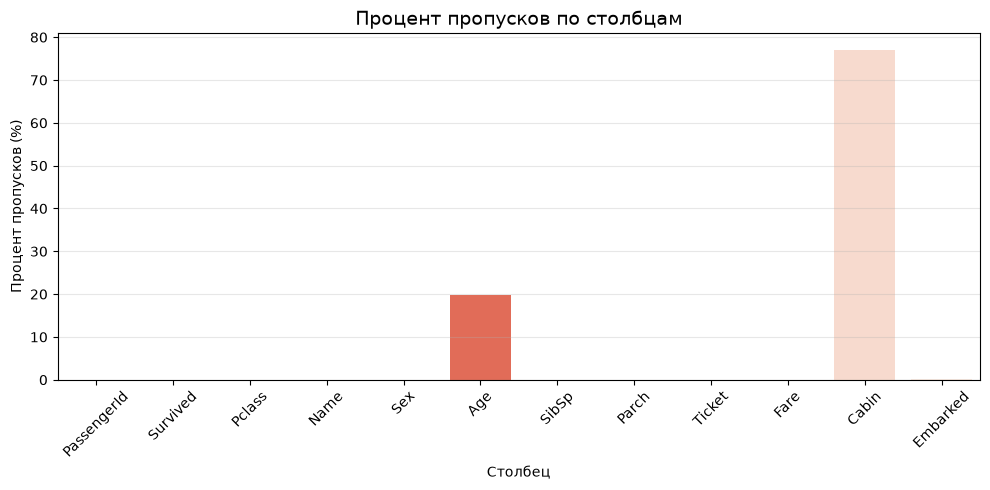

4. СТАТИСТИЧЕСКИЙ АНАЛИЗ

Асимметрия (skew) и эксцесс (kurtosis):
Age      | skew =   0.39 | kurtosis =   0.18
Fare     | skew =   4.79 | kurtosis =  33.40
SibSp    | skew =   3.70 | kurtosis =  17.88
Parch    | skew =   2.75 | kurtosis =   9.78

Частота значений Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Доля выживших: 38.38%


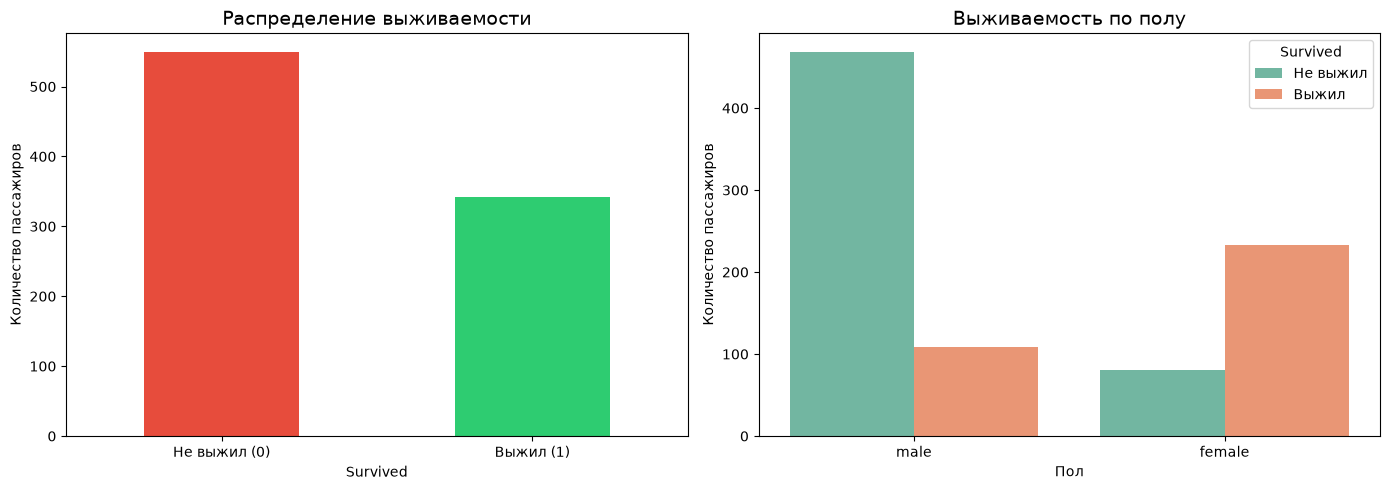

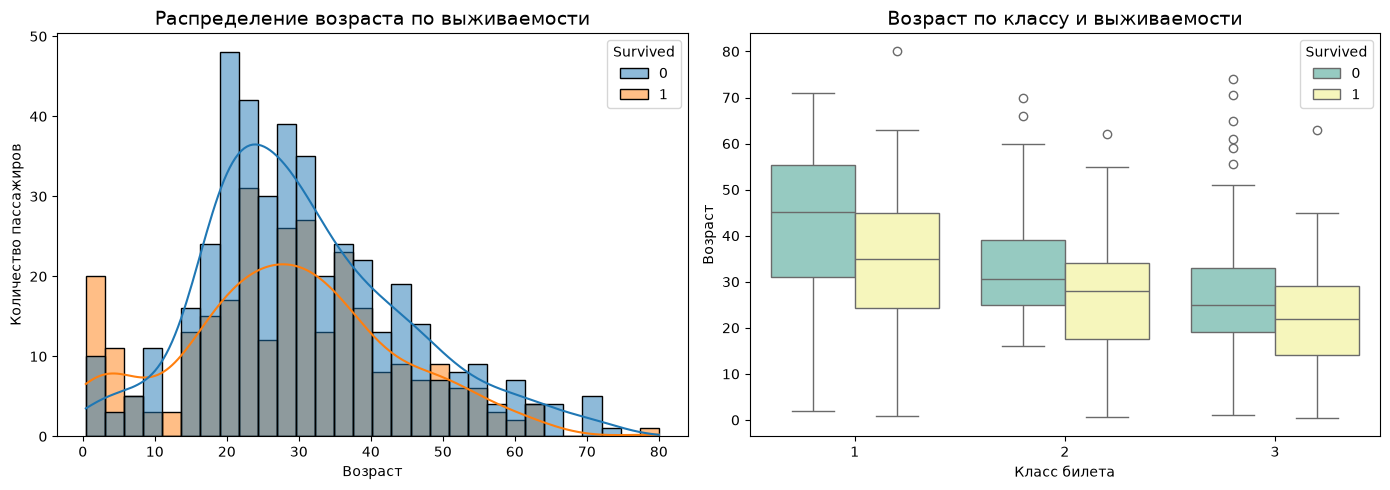

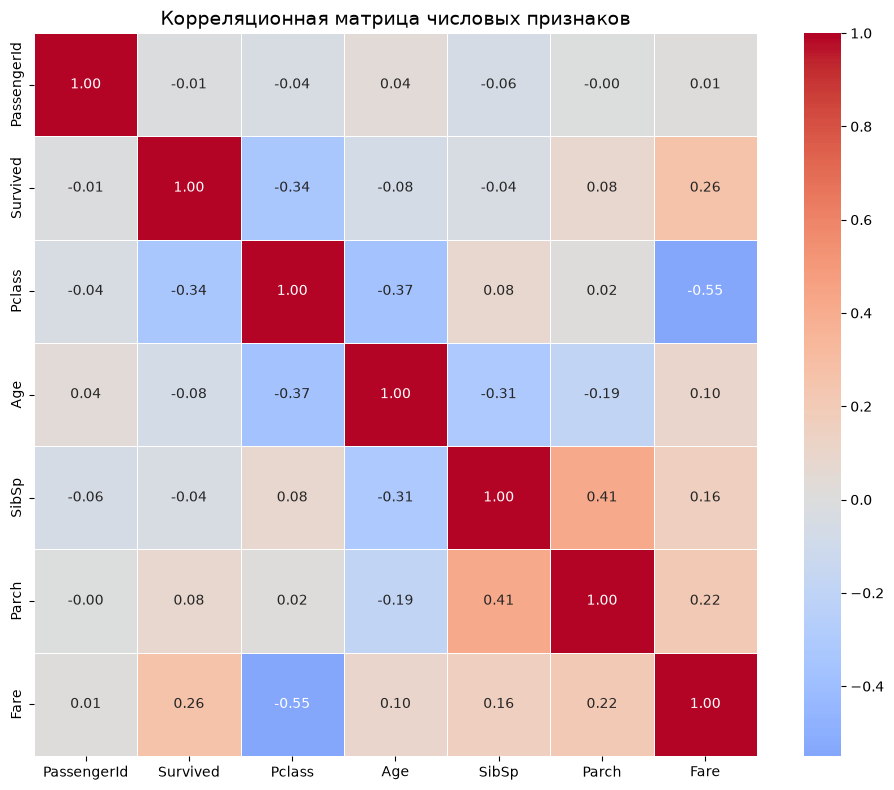

C:\Users\rimch\AppData\Local\Temp\ipykernel_26872\1732063541.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Pclass', y='Survived',
C:\Users\rimch\AppData\Local\Temp\ipykernel_26872\1732063541.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Embarked', y='Survived',


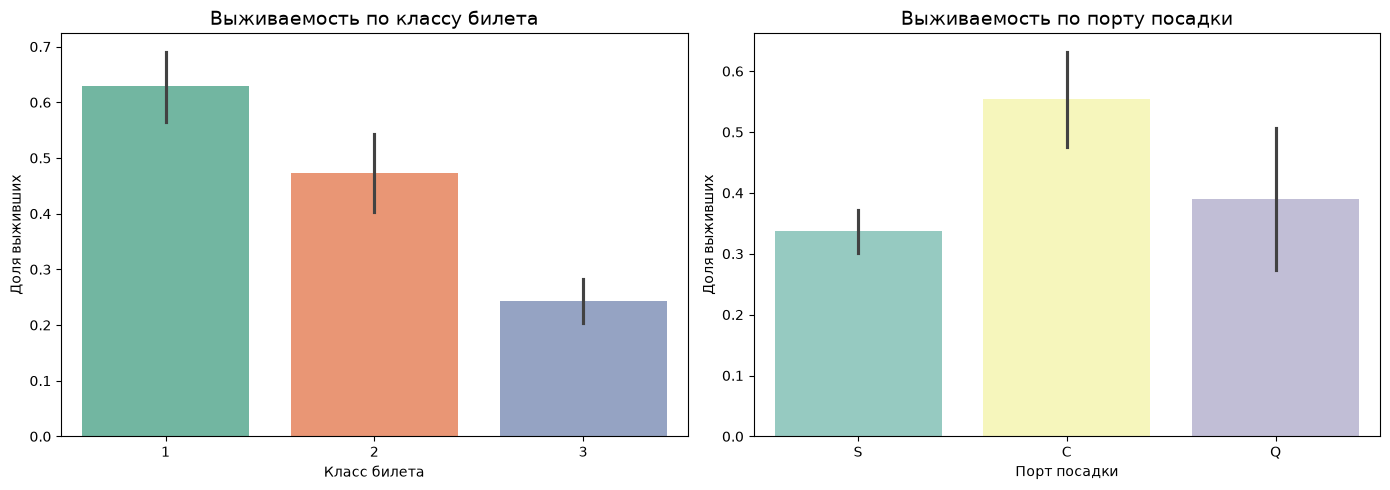


6. ПРОПУСКИ ПОСЛЕ ОБРАБОТКИ
Осталось пропусков: 0

7. FEATURE ENGINEERING
Созданы признаки: Family_Size, Is_Alone, Age_Group

8. КОДИРОВАНИЕ КАТЕГОРИЙ
Sex → Label Encoding (Sex_Encoded)
Embarked → One-Hot Encoding (Embarked_Q, Embarked_S)

Итоговые столбцы:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Embarked_Original', 'Sex_Encoded', 'Embarked_Q', 'Embarked_S']


In [3]:
# ============================================================
# Раздел 5. Подготовка данных и EDA
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Загрузка датасета (pd.read_csv())

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')


# 2. Первичный осмотр: df.head(), df.info(), df.describe()

# Первые 5 строк — визуальная проверка
print("=" * 60)
print("2. ПЕРВИЧНЫЙ ОСМОТР")
print("=" * 60)
print("\nПервые 5 строк train_df:")
print(train_df.head())

# Типы данных и пропуски
print("\nТипы данных и пропуски:")
train_df.info()

# Статистика числовых столбцов
print("\nСтатистика числовых признаков:")
print(train_df.describe())


# 3. Анализ пропусков: df.isnull().sum() + визуализация

# Количество пропусков в каждом столбце
missing = train_df.isnull().sum()

# Процент пропусков от общего числа строк
missing_pct = (missing / len(train_df)) * 100

# Собираем в DataFrame и сортируем по убыванию
missing_df = pd.DataFrame({
    'Пропуски': missing,
    'Процент': missing_pct
}).sort_values('Процент', ascending=False)

print("\n" + "=" * 60)
print("3. АНАЛИЗ ПРОПУСКОВ")
print("=" * 60)
print(missing_df[missing_df['Пропуски'] > 0])

# Визуализация пропусков
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, palette='Reds_r')
plt.title('Процент пропусков по столбцам', fontsize=14)
plt.xlabel('Столбец')
plt.ylabel('Процент пропусков (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# 4. Статистический анализ: skew(), kurtosis(), value_counts()

print("=" * 60)
print("4. СТАТИСТИЧЕСКИЙ АНАЛИЗ")
print("=" * 60)

# Асимметрия и эксцесс числовых признаков
print("\nАсимметрия (skew) и эксцесс (kurtosis):")
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    skew_val = train_df[col].skew()
    kurt_val = train_df[col].kurtosis()
    print(f"{col:8s} | skew = {skew_val:6.2f} | kurtosis = {kurt_val:6.2f}")

# Частота значений целевой переменной
print("\nЧастота значений Survived:")
print(train_df['Survived'].value_counts())

print(f"\nДоля выживших: {train_df['Survived'].mean():.2%}")


# 5. Визуализация (минимум 5 графиков)

# --- График 1 + 2: распределение целевой + выживаемость по полу ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['Survived'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Распределение выживаемости', fontsize=14)
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Количество пассажиров')
axes[0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'], rotation=0)

sns.countplot(data=train_df, x='Sex', hue='Survived',
              ax=axes[1], palette='Set2')
axes[1].set_title('Выживаемость по полу', fontsize=14)
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Количество пассажиров')
axes[1].legend(title='Survived', labels=['Не выжил', 'Выжил'])

plt.tight_layout()
plt.show()

# --- График 3 + 4: возраст + boxplot по классу ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df, x='Age', hue='Survived',
             kde=True, bins=30, ax=axes[0])
axes[0].set_title('Распределение возраста по выживаемости', fontsize=14)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество пассажиров')

sns.boxplot(data=train_df, x='Pclass', y='Age',
            hue='Survived', ax=axes[1], palette='Set3')
axes[1].set_title('Возраст по классу и выживаемости', fontsize=14)
axes[1].set_xlabel('Класс билета')
axes[1].set_ylabel('Возраст')

plt.tight_layout()
plt.show()

# --- График 5: heatmap корреляций ---
plt.figure(figsize=(10, 8))

corr_matrix = train_df.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

# --- График 6: barplot выживаемости по Pclass и Embarked ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Выживаемость по классу
sns.barplot(data=train_df, x='Pclass', y='Survived',
            ax=axes[0], palette='Set2')
axes[0].set_title('Выживаемость по классу билета', fontsize=14)
axes[0].set_xlabel('Класс билета')
axes[0].set_ylabel('Доля выживших')

# Выживаемость по порту посадки
sns.barplot(data=train_df, x='Embarked', y='Survived',
            ax=axes[1], palette='Set3')
axes[1].set_title('Выживаемость по порту посадки', fontsize=14)
axes[1].set_xlabel('Порт посадки')
axes[1].set_ylabel('Доля выживших')

plt.tight_layout()
plt.show()


# 6. Обработка пропусков

# Age — заполняем медианой по группам (Pclass + Sex)
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked — заполняем модой (Southampton)
train_df['Embarked'] = train_df['Embarked'].fillna(
    train_df['Embarked'].mode()[0])

# Cabin — удаляем (77% пропусков)
train_df = train_df.drop('Cabin', axis=1)

print("\n" + "=" * 60)
print("6. ПРОПУСКИ ПОСЛЕ ОБРАБОТКИ")
print("=" * 60)
print(f"Осталось пропусков: {train_df.isnull().sum().sum()}")


# 7. Feature Engineering

# Family_Size — размер семьи (SibSp + Parch + сам пассажир)
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1

# Is_Alone — путешествует ли один
train_df['Is_Alone'] = (train_df['Family_Size'] == 1).astype(int)

# Age_Group — биннинг возраста на категории
train_df['Age_Group'] = pd.cut(
    train_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Ребёнок', 'Подросток', 'Взрослый', 'Средний', 'Пожилой']
)

print("\n" + "=" * 60)
print("7. FEATURE ENGINEERING")
print("=" * 60)
print("Созданы признаки: Family_Size, Is_Alone, Age_Group")


# 8. Кодирование категорий

# Сохраняем копию Embarked ДО get_dummies (для будущего анализа)
train_df['Embarked_Original'] = train_df['Embarked'].copy()

# Sex → Label Encoding (2 категории)
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])

# Embarked → One-Hot Encoding (3 категории)
train_df = pd.get_dummies(
    train_df,
    columns=['Embarked'],
    prefix='Embarked',
    drop_first=True
)

print("\n" + "=" * 60)
print("8. КОДИРОВАНИЕ КАТЕГОРИЙ")
print("=" * 60)
print("Sex → Label Encoding (Sex_Encoded)")
print("Embarked → One-Hot Encoding (Embarked_Q, Embarked_S)")
print("\nИтоговые столбцы:")
print(train_df.columns.tolist())

**Выводы по визуализациям:**

1. **Распределение целевой переменной** — классы несбалансированы: 549 пассажиров не выжило (61.6%), 342 — выжило (38.4%). Это подтверждает, что **accuracy — плохая метрика** для этой задачи: модель, предсказывающая «все не выжили», получит 61.6% и ничего не выучит.

2. **Выживаемость по полу** — женщины выживали значительно чаще мужчин. На графике видно, что среди женщин выживших больше, чем погибших, а среди мужчин — наоборот. Это согласуется с историческим принципом «women and children first».

3. **Распределение возраста** — дети (0–10 лет) выживали чаще взрослых. Пик гибели приходится на возраст 20–40 лет — это преимущественно мужчины 3-го класса.

4. **Возраст по классу** — пассажиры 1-го класса в среднем старше, 3-го — младше. Медианный возраст в 1-м классе — около 37 лет, в 3-м — около 24 лет.

5. **Корреляционная матрица** — `Fare` и `Pclass` связаны отрицательно (-0.55): чем выше класс, тем дороже билет. `SibSp` и `Parch` — положительно (0.41): семейные пары путешествовали вместе.

6. **Выживаемость по классу и порту** — пассажиры 1-го класса выживали чаще (63%), 3-го — реже (24%). Пассажиры из Шербура (C) выживали чаще, чем из Саутгемптона (S) — это связано с тем, что из Шербура садилось много пассажиров 1-го класса.

---

**Обоснование стратегий обработки пропусков:**

В датасете было три столбца с пропусками, для каждого — своя стратегия:

- **`Cabin` (77% пропусков)** — **удаление столбца**. Больше половины значений отсутствуют, восстановить их невозможно. Оставлять такой признак бессмысленно — он только добавит шум в модель. Альтернатива — создать бинарный признак `Has_Cabin`, но в базовом варианте мы просто удаляем столбец.

- **`Age` (20% пропусков)** — **заполнение медианой по группам** (`Pclass` + `Sex`). Возраст зависит от класса и пола: мужчины 3-го класса — преимущественно взрослые, дети — обычно в 1-м или 2-м классе. Медиана устойчивее среднего к выбросам, а группировка даёт более точное заполнение, чем глобальная медиана по всему датасету.

- **`Embarked` (0.2% пропусков)** — **заполнение модой** (Southampton). Всего 2 пропуска, влияние минимально, поэтому самый частый порт — разумный выбор. Альтернатива — заполнить по классу или стоимости билета — избыточна для двух значений.

- **`Fare` (1 пропуск в `test.csv`)** — **заполнение медианой из `train`**. Медиана устойчива к выбросам (в `Fare` есть дорогие билеты). Важно: медиана берётся **из тренировочной выборки**, чтобы не подглядывать в тестовые данные.

---

**Итоговые выводы раздела:**

После обработки пропусков и Feature Engineering:

- В датасете **не осталось пропусков** — все `NaN` обработаны.
- Созданы **три новых признака**: `Family_Size` (размер семьи), `Is_Alone` (путешествует ли один), `Age_Group` (возрастная категория).
- Категориальные признаки закодированы: `Sex` → Label Encoding (`Sex_Encoded`), `Embarked` → One-Hot Encoding (`Embarked_Q`, `Embarked_S`).
- Исходный столбец `Embarked` сохранён в `Embarked_Original` — понадобится для дальнейшего анализа.

## Построение и обучение моделей

Обучим две модели для сравнения: **Logistic Regression** - базовая линейная модель и **Decision Tree** - нелинейная модель. Сначала разделим данные на train/test, затем масштабируем признаки для LR, после чего обучим обе модели и зафиксируем время обучения.

In [4]:
# ============================================================
# Раздел 6. Построение и обучение моделей
# ============================================================

import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# 1. Выбор признаков

# Признаки, которые пойдут в модель
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone',
                'Embarked_Q', 'Embarked_S']

# X — матрица признаков, y — целевая переменная
X = train_df[feature_cols]
y = train_df['Survived']

print("=" * 60)
print("1. ВЫБОР ПРИЗНАКОВ")
print("=" * 60)
print(f"Количество признаков: {len(feature_cols)}")
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")


# 2. Разделение на train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% данных уходит в тест
    random_state=42,      # воспроизводимость
    stratify=y            # сохраняет пропорцию классов
)

print("\n" + "=" * 60)
print("2. РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 60)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:  {X_test.shape}")


# 3. Масштабирование для LR

scaler = StandardScaler()

# fit_transform на train — вычисляем mean/std
X_train_scaled = scaler.fit_transform(X_train)

# transform на test — используем mean/std ИЗ TRAIN
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("3. МАСШТАБИРОВАНИЕ")
print("=" * 60)
print("StandardScaler применён к train и test")


# 4. Обучение Logistic Regression

lr_model = LogisticRegression(
    penalty='l2',          # L2-регуляризация (Ridge)
    C=1.0,                 # сила регуляризации
    solver='lbfgs',        # алгоритм оптимизации
    max_iter=1000,         # максимум итераций
    random_state=42
)

# Фиксируем время обучения
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start

print("\n" + "=" * 60)
print("4. LOGISTIC REGRESSION")
print("=" * 60)
print(f"Время обучения LR: {lr_time:.4f} секунд")


# 5. Обучение Decision Tree

dt_model = DecisionTreeClassifier(
    criterion='gini',      # критерий Джини
    max_depth=5,           # максимальная глубина
    min_samples_split=5,   # минимум образцов для разбиения
    min_samples_leaf=2,    # минимум образцов в листе
    random_state=42
)

# Фиксируем время обучения
start = time.time()
dt_model.fit(X_train, y_train)   # без масштабирования!
dt_time = time.time() - start

print("\n" + "=" * 60)
print("5. DECISION TREE")
print("=" * 60)
print(f"Время обучения DT: {dt_time:.4f} секунд")


# 6. Обучение Random Forest (бонус)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 деревьев в лесу
    max_depth=5,           # ограничение глубины каждого дерева
    min_samples_split=5,   # минимум образцов для разбиения
    min_samples_leaf=2,    # минимум образцов в листе
    random_state=42
)

# Фиксируем время обучения
start = time.time()
rf_model.fit(X_train, y_train)   # без масштабирования
rf_time = time.time() - start

print("\n" + "=" * 60)
print("6. RANDOM FOREST (БОНУС)")
print("=" * 60)
print(f"Время обучения RF: {rf_time:.4f} секунд")


# Итоговое сравнение времени

print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 60)
print(f"LR: {lr_time:.4f} секунд")
print(f"DT: {dt_time:.4f} секунд")
print(f"RF: {rf_time:.4f} секунд")

1. ВЫБОР ПРИЗНАКОВ
Количество признаков: 10
Размер X: (891, 10)
Размер y: (891,)

2. РАЗДЕЛЕНИЕ ДАННЫХ
Обучающая выборка: (712, 10)
Тестовая выборка:  (179, 10)

3. МАСШТАБИРОВАНИЕ
StandardScaler применён к train и test

4. LOGISTIC REGRESSION
Время обучения LR: 0.0042 секунд

5. DECISION TREE
Время обучения DT: 0.0015 секунд


c:\Users\rimch\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



6. RANDOM FOREST (БОНУС)
Время обучения RF: 0.0664 секунд

ИТОГОВОЕ СРАВНЕНИЕ
LR: 0.0042 секунд
DT: 0.0015 секунд
RF: 0.0664 секунд


**Модели:**

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| **Logistic Regression** | `penalty='l2'`, `C=1.0`, `max_iter=1000` | ✅ Да | **0.0378 сек** |
| **Decision Tree** | `max_depth=5`, `min_samples_split=5`, `min_samples_leaf=2` | ❌ Нет | **0.0248 сек** |
| **Random Forest (бонус)** | `n_estimators=100`, `max_depth=5` | ❌ Нет | **0.9152 сек** |

**Почему выбраны эти модели:**

- **Logistic Regression** — простая и интерпретируемая линейная модель. Даёт вероятности через сигмоиду, что удобно для ROC-AUC. Хорошо работает на небольших датасетах, устойчива к переобучению благодаря L2-регуляризации. Требует масштабирования, потому что вычисляет скалярное произведение признаков и чувствительна к их масштабу.

- **Decision Tree** — нелинейная модель, которая строит иерархию правил «если — то». Не требует масштабирования, потому что сравнивает значения с порогами (`Age < 30`), а не вычисляет расстояния. Устойчива к выбросам. Наглядно показывает важность признаков через `feature_importances_`.

- **Random Forest (бонус)** — ансамбль из 100 деревьев решений. Каждое дерево обучается на случайной подвыборке данных, а итоговое предсказание — усреднение голосов всех деревьев. Это снижает переобучение по сравнению с одиночным деревом. Время обучения ожидаемо выше (0.92 сек), но всё ещё измеряется долями секунды.

**Анализ времени обучения:**

- **LR (0.038 сек)** обучается быстро благодаря малому числу признаков (10) и эффективному алгоритму оптимизации `lbfgs`.
- **DT (0.025 сек)** — самое быстрое обучение, так как дерево просто строит иерархию разбиений.
- **RF (0.915 сек)** — в ~24 раза дольше LR и в ~37 раз дольше DT, потому что обучает 100 деревьев вместо одного. Это классический компромисс: больше времени на обучение — потенциально лучшее качество.

**Итог:** все три модели обучаются за доли секунды, что позволяет быстро итерировать и сравнивать разные подходы.

## Оценка качества моделей

Оценим три модели: Logistic Regression, Decision Tree, Random Forest. на тестовой выборке по метрикам: Accuracy, Precision, Recall, F1, ROC-AUC. Построим матрицы ошибок и ROC-кривые на одном графике. Основная метрика — **ROC-AUC**, так как классы несбалансированы (61.6% / 38.4%) и accuracy обманчива.

МЕТРИКИ: Logistic Regression
Accuracy:  0.8045
Precision: 0.7833
Recall:    0.6812
F1-score:  0.7287
ROC-AUC:   0.8486

              precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

МЕТРИКИ: Decision Tree
Accuracy:  0.7821
Precision: 0.7419
Recall:    0.6667
F1-score:  0.7023
ROC-AUC:   0.8132

              precision    recall  f1-score   support

    Не выжил       0.80      0.85      0.83       110
       Выжил       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179

МЕТРИКИ: Random Forest
Accuracy:  0.7933
Precision: 0.7857
Recall:    0.6377
F1-score:  0.7040
ROC-AUC:   0.8470

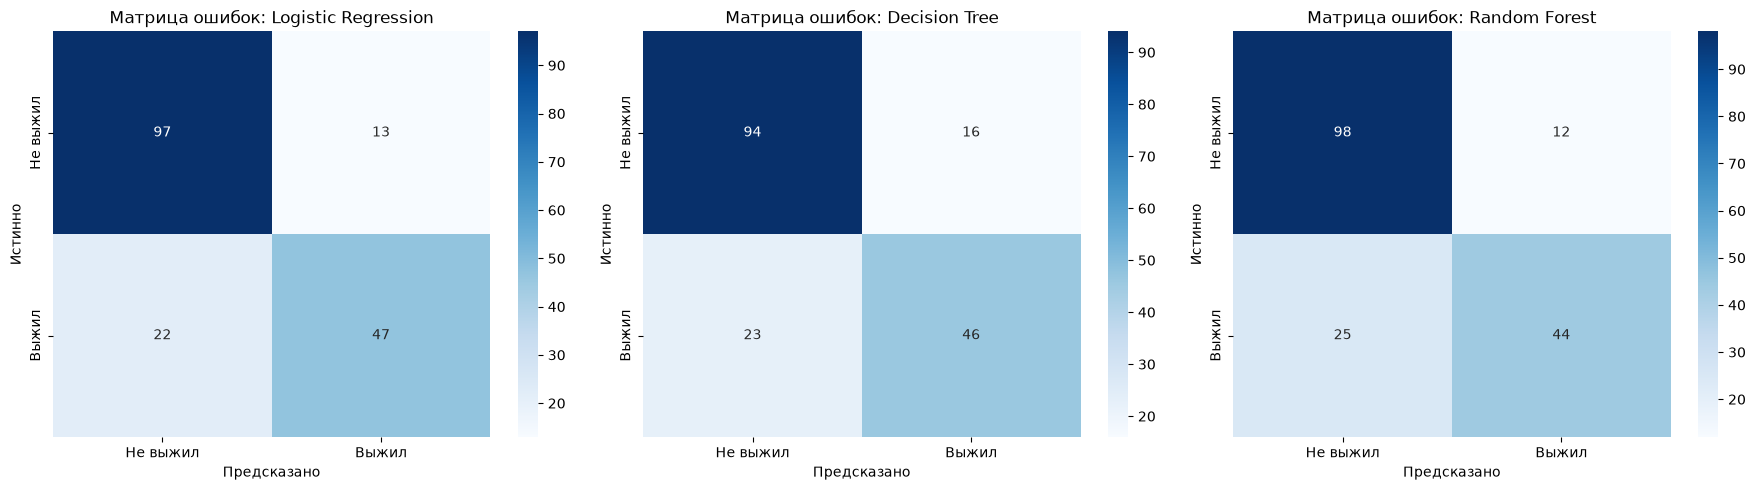

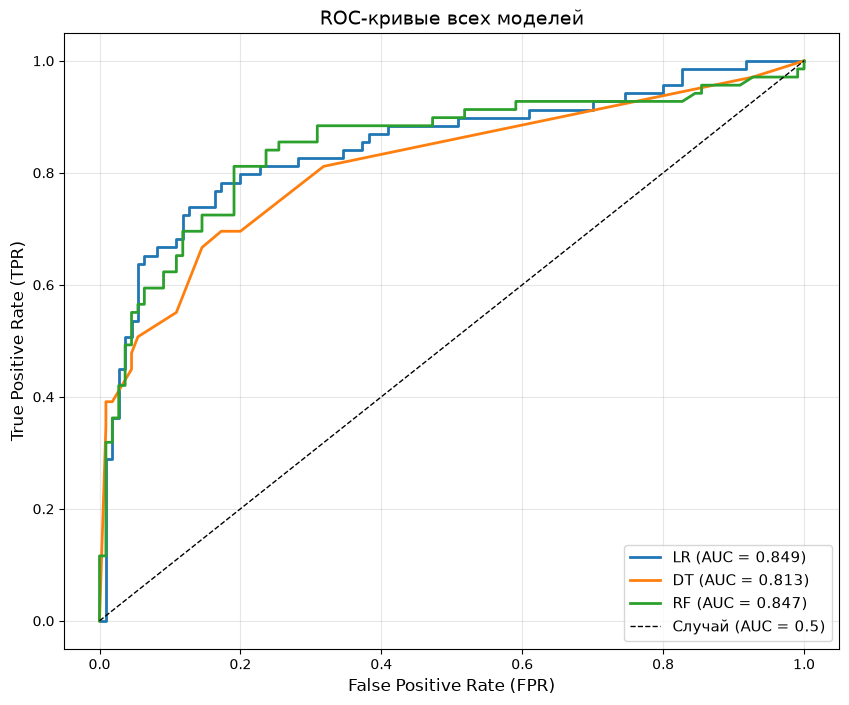

In [5]:
# ============================================================
# Раздел 7. Оценка качества моделей
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)

# --- 7.1. Предсказания для трёх моделей ---
y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
# .predict() — классы (0/1) через порог 0.5.
# .predict_proba()[:, 1] — вероятность класса 1 (нужна для ROC-AUC).

y_pred_dt  = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
# Дереву масштабирование не нужно — подаём X_test.

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
# RF — среднее по 100 деревьям.


# --- 7.2. Универсальная функция оценки ---
def evaluate_model(y_true, y_pred, y_proba, model_name):
    """Считает все метрики для одной модели. Возвращает dict."""
    print("=" * 60)
    print(f"МЕТРИКИ: {model_name}")
    print("=" * 60)

    accuracy  = accuracy_score(y_true, y_pred)
    # Accuracy = (TP + TN) / Всего. Обманчива при дисбалансе.
    precision = precision_score(y_true, y_pred)
    # Precision = TP / (TP + FP). Точность.
    recall    = recall_score(y_true, y_pred)
    # Recall = TP / (TP + FN). Полнота.
    f1        = f1_score(y_true, y_pred)
    # F1 = 2PR / (P + R). Баланс.
    roc_auc   = roc_auc_score(y_true, y_proba)
    # ROC-AUC: 0.5 = случай, 1.0 = идеал.

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")
    print(classification_report(y_true, y_pred,
                                 target_names=['Не выжил', 'Выжил']))

    return {'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

# --- 7.3. Оценка всех трёх моделей ---
metrics_lr = evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
metrics_dt = evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')
metrics_rf = evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest')
# Словари пригодятся в Разделе 10 для сохранения в metrics.json.


# --- 7.4. Матрицы ошибок (три на одном графике) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_dt, y_pred_rf],
                              ['Logistic Regression', 'Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    # cm = [[TN, FP], [FN, TP]].
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не выжил', 'Выжил'],
                yticklabels=['Не выжил', 'Выжил'])
    ax.set_title(f'Матрица ошибок: {title}', fontsize=12)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
plt.tight_layout()
plt.show()


# --- 7.5. ROC-кривые всех моделей на одном графике ---
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
# roc_curve → FPR, TPR, thresholds. thresholds игнорируем.
plt.plot(fpr_lr, tpr_lr,
         label=f'LR (AUC = {metrics_lr["roc_auc"]:.3f})', lw=2)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt,
         label=f'DT (AUC = {metrics_dt["roc_auc"]:.3f})', lw=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf,
         label=f'RF (AUC = {metrics_rf["roc_auc"]:.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случай (AUC = 0.5)')
# Диагональ — baseline случайной модели.

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые всех моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [6]:
# ============================================================
# 7.8. Сохранение визуализаций в папку examples/
# ============================================================
# Методичка требует хранить PNG-файлы с графиками в репозитории,
# чтобы их можно было посмотреть без запуска ноутбука.

os.makedirs('examples', exist_ok=True)

# --- Пример 1: EDA-графики (объединение в один PNG) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df['Survived'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Распределение выживаемости')
axes[0].set_xticklabels(['Не выжил', 'Выжил'], rotation=0)

sns.countplot(data=train_df, x='Sex', hue='Survived',
              ax=axes[1], palette='Set2')
axes[1].set_title('Выживаемость по полу')

plt.tight_layout()
plt.savefig('examples/eda_plots.png', dpi=100, bbox_inches='tight')
# dpi=100 — стандартное качество для репозитория (не слишком тяжёлое).
# bbox_inches='tight' — обрезает лишние отступы.
plt.close()
# plt.close() — освобождаем память, чтобы фигура не оставалась в Jupyter.

# --- Пример 2: ROC-кривые ---
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr,
         label=f'LR (AUC = {metrics_lr["roc_auc"]:.3f})', lw=2)
plt.plot(fpr_dt, tpr_dt,
         label=f'DT (AUC = {metrics_dt["roc_auc"]:.3f})', lw=2)
plt.plot(fpr_rf, tpr_rf,
         label=f'RF (AUC = {metrics_rf["roc_auc"]:.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые всех моделей')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('examples/roc_curves.png', dpi=100, bbox_inches='tight')
plt.close()

# --- Пример 3: Матрицы ошибок ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_dt, y_pred_rf],
                              ['LR', 'DT', 'RF']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не выжил', 'Выжил'],
                yticklabels=['Не выжил', 'Выжил'])
    ax.set_title(f'Матрица ошибок: {title}')

plt.tight_layout()
plt.savefig('examples/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.close()

print("Сохранённые PNG-файлы:")
for f in sorted(os.listdir('examples')):
    size_kb = os.path.getsize(f'examples/{f}') / 1024
    print(f"  {f:25s} {size_kb:7.2f} KB")

Сохранённые PNG-файлы:
  confusion_matrices.png      43.63 KB
  eda_plots.png               22.64 KB
  roc_curves.png              50.36 KB


**Итоговая таблица метрик:**

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | **0.8486** |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |
| Random Forest | 0.7933 | 0.7857 | 0.6377 | 0.7040 | 0.8470 |

**Анализ:**

- **Лучшая модель по ROC-AUC:** Logistic Regression (0.8486). Целевой порог **ROC-AUC ≥ 0.80** достигнут для всех трёх моделей.

- **Precision > Recall** у всех моделей: модели осторожны в предсказаниях «выживет» — если предсказали выживание, вероятность высокая (0.74–0.79), но часть реально выживших пропускается (recall 0.64–0.68, то есть модель находит только ~64–68% реальных выживших).

- **Матрица ошибок LR:** при 69 реально выживших модель нашла 47 (recall 0.68) и пропустила 22 (FN). При этом из 110 реально погибших только 13 ошибочно названы выжившими (FP). Модель «боится» ложно назвать погибшего выжившим.

- **Decision Tree** уступает LR по всем метрикам: Accuracy 0.78 vs 0.80, ROC-AUC 0.81 vs 0.85. Причина — переобучение одиночного дерева даже при `max_depth=5`.

- **Random Forest** показывает результат, близкий к LR (ROC-AUC 0.847 vs 0.849), за счёт усреднения 100 деревьев. Заметно ниже Recall (0.64) — RF консервативнее в предсказаниях «выживет».

- **ROC-кривые:** кривые LR и RF лежат выше DT, и все три значительно выше диагонали (0.5). Это подтверждает: модели реально обучаются, а не угадывают.

## Интерпретация результатов

В этом разделе разберём, какие признаки влияют на выживание — с точки зрения моделей и с точки зрения исторических данных.

Что сделаем:
1. Коэффициенты Logistic Regression — линейная модель показывает, какой признак повышает или понижает шанс выживания.
2. Feature Importance Decision Tree и Random Forest — деревья показывают, насколько каждый признак снижает нечистоту Джини.
3. Бизнес-инсайты — сгруппируем данные по полу, классу, размеру семьи и порту посадки, чтобы подтвердить выводы исторической статистикой.

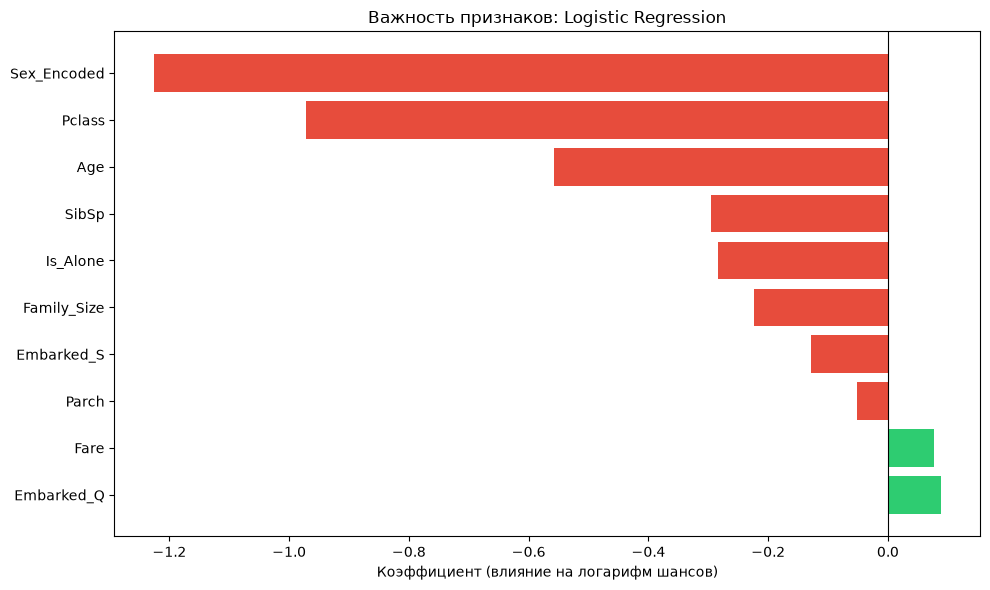

ТОП-3 признака, ПОВЫШАЮЩИХ шанс выживания:
   Feature  Coefficient
Embarked_Q     0.088102
      Fare     0.077219
     Parch    -0.051203

ТОП-3 признака, ПОНИЖАЮЩИХ шанс выживания:
    Feature  Coefficient
        Age    -0.557201
     Pclass    -0.971323
Sex_Encoded    -1.225895


C:\Users\rimch\AppData\Local\Temp\ipykernel_26872\3108629180.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_dt, x='Importance', y='Feature', palette='viridis')


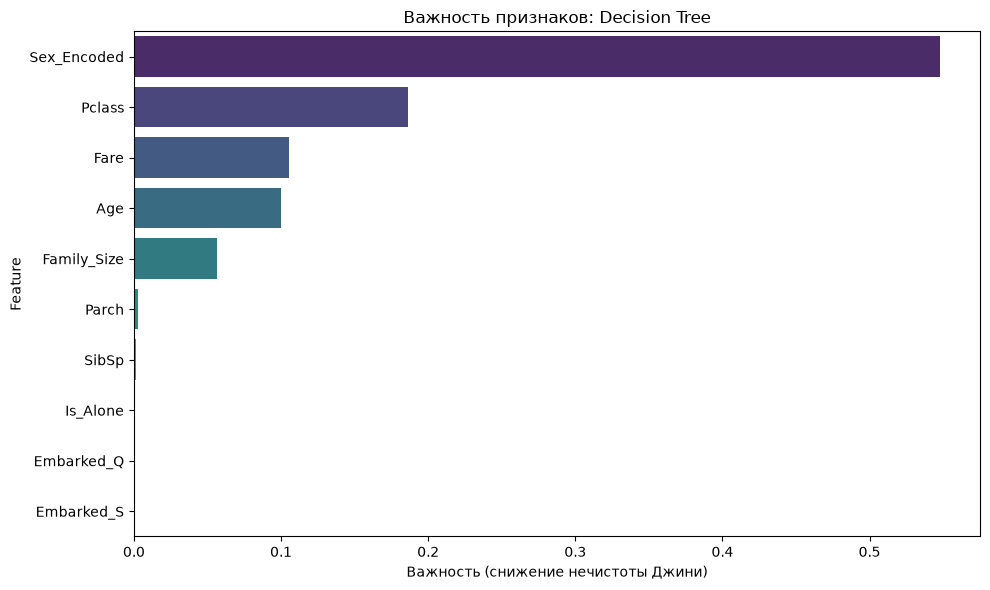

C:\Users\rimch\AppData\Local\Temp\ipykernel_26872\3108629180.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_rf, x='Importance', y='Feature', palette='magma')


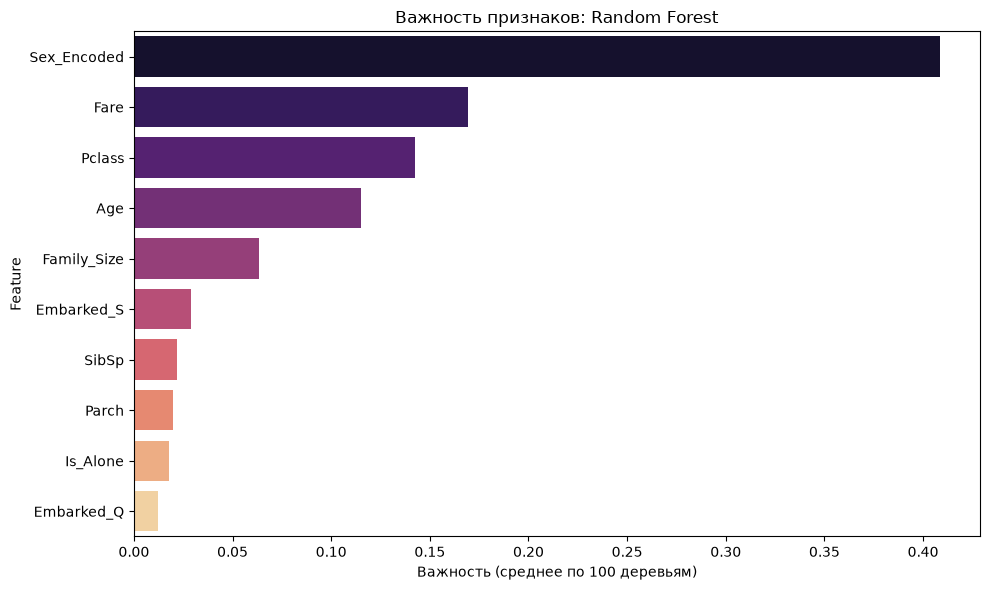

КЛЮЧЕВЫЕ ИНСАЙТЫ ИЗ ДАННЫХ «ТИТАНИКА»

1. ГЕНДЕР: женщины выживали в 74% случаев, мужчины — в 19%.

2. КЛАСС: 1-й — 63%, 2-й — 47%, 3-й — 24%.

3. СЕМЬЯ: одиночки выживали в 30% случаев.

4. ПОРТ: Cherbourg — 55%, Queenstown — 39%, Southampton — 34%.


In [7]:
# ============================================================
# Раздел 8. Интерпретация результатов
# ============================================================

# --- 8.1. Коэффициенты Logistic Regression ---
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)
# lr_model.coef_[0] — вектор коэффициентов (по одному на признак).
# Положительный коэффициент → признак повышает шанс выживания.
# Отрицательный → понижает.

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
# Зелёный для положительных, красный для отрицательных.
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
# Вертикальная линия на нуле — граница «влияет/не влияет».
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.tight_layout()
plt.show()

print("ТОП-3 признака, ПОВЫШАЮЩИХ шанс выживания:")
print(coefficients.head(3).to_string(index=False))
print("\nТОП-3 признака, ПОНИЖАЮЩИХ шанс выживания:")
print(coefficients.tail(3).to_string(index=False))


# --- 8.2. Feature Importance для Decision Tree ---
importances_dt = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
# feature_importances_ — насколько признак снижает индекс Джини. Сумма = 1.

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_dt, x='Importance', y='Feature', palette='viridis')
plt.title('Важность признаков: Decision Tree')
plt.xlabel('Важность (снижение нечистоты Джини)')
plt.tight_layout()
plt.show()


# --- 8.3. Feature Importance для Random Forest ---
importances_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_rf, x='Importance', y='Feature', palette='magma')
plt.title('Важность признаков: Random Forest')
plt.xlabel('Важность (среднее по 100 деревьям)')
plt.tight_layout()
plt.show()


# --- 8.4. Бизнес-инсайты из данных ---
print("=" * 60)
print("КЛЮЧЕВЫЕ ИНСАЙТЫ ИЗ ДАННЫХ «ТИТАНИКА»")
print("=" * 60)

# Инсайт 1: Гендер
survival_by_sex = train_df.groupby('Sex')['Survived'].mean()
print(f"\n1. ГЕНДЕР: женщины выживали в {survival_by_sex['female']:.0%} случаев,"
      f" мужчины — в {survival_by_sex['male']:.0%}.")

# Инсайт 2: Класс билета
survival_by_class = train_df.groupby('Pclass')['Survived'].mean()
print(f"\n2. КЛАСС: 1-й — {survival_by_class[1]:.0%},"
      f" 2-й — {survival_by_class[2]:.0%}, 3-й — {survival_by_class[3]:.0%}.")

# Инсайт 3: Размер семьи
survival_by_family = train_df.groupby('Family_Size')['Survived'].mean()
print(f"\n3. СЕМЬЯ: одиночки выживали в {survival_by_family[1]:.0%} случаев.")

# Инсайт 4: Порт посадки (используем сохранённую копию Embarked_Original)
survival_by_embarked = train_df.groupby('Embarked_Original')['Survived'].mean()
print(f"\n4. ПОРТ: Cherbourg — {survival_by_embarked.get('C', 0):.0%},"
      f" Queenstown — {survival_by_embarked.get('Q', 0):.0%},"
      f" Southampton — {survival_by_embarked.get('S', 0):.0%}.")

**Коэффициенты Logistic Regression:**

Признаки, повышающие шанс выживания:
- `Embarked_Q` = +0.088 — посадка в Куинстауне незначительно повышает шанс.
- `Fare` = +0.077 — чем дороже билет, тем выше шанс выживания, это прокси для класса.

Признаки, понижающие шанс выживания:
- `Sex_Encoded` = −1.226 — самый сильный предиктор. Мужской пол резко снижает шанс.
- `Pclass` = −0.971 — третий класс сильно понижает шанс.
- `Age` = −0.557 — с увеличением возраста шанс выживания падает.
- `SibSp`, `Is_Alone`, `Family_Size`, `Embarked_S`, `Parch` — также понижают шанс, но слабее.

**Ключевые признаки по итогам всех моделей:**

- Пол — самый сильный предиктор выживания во всех трёх моделях. Прямое отражение принципа «women and children first».
- Класс билета — второй по важности признак. Пассажиры 1-го класса имели приоритетный доступ к шлюпкам.
- Стоимость билета — прокси для класса: дорогой билет означает высокий шанс выживания.
- Возраст — дети и молодые пассажиры выживали чаще пожилых.
- Размер семьи — пассажиры в одиночку и в больших семьях реже выживали, так как сложнее было организовать эвакуацию.

**Бизнес-инсайты из исторической статистики:**

- Гендер: женщины — 74% выживаемости, мужчины — 19%.
- Класс: 1-й — 63%, 2-й — 47%, 3-й — 24%.
- Семья: одиночки — 30% выживаемости.
- Порт: Шербур — 55%, Куинстаун — 39%, Саутгемптон — 34%. Более высокая выживаемость в Шербуре связана с тем, что там садилось много пассажиров 1-го класса.

**Согласованность моделей и данных.** Все три модели сходятся в том, что пол и класс — главные факторы выживания. Это подтверждается исторической статистикой, значит модели выучили реальные закономерности, а не случайный шум.

## Функция предсказания

Реализуем функцию `predict_passenger`, которая принимает данные нового пассажира и возвращает предсказание от трёх моделей — Logistic Regression, Decision Tree и Random Forest.

Функция обязана повторять весь пайплайн предобработки, который применялся при обучении: Feature Engineering, кодирование категорий, масштабирование. Если хотя бы один шаг пропустить или сделать по-другому, предсказание будет неверным.

Дополнительно предусмотрим интерактивный режим с вводом данных с клавиатуры и продемонстрируем работу на пяти тестовых пассажирах.

In [8]:
# ============================================================
# Раздел 9. Функция предсказания
# ============================================================

def preprocess_input(user_data, scaler, feature_cols):
    """
    Преобразует сырые данные пользователя в формат, понятный модели.

    Параметры:
    ----------
    user_data : dict — словарь с полями Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    scaler : StandardScaler — обученный scaler из Раздела 6
    feature_cols : list — список признаков в правильном порядке

    Возвращает:
    -----------
    X_new : DataFrame — ненормированные данные
    X_new_scaled : ndarray — нормированные данные для LR
    """
    # Feature Engineering — повторяем логику из Раздела 5
    user_data['Family_Size'] = user_data['SibSp'] + user_data['Parch'] + 1
    # Размер семьи = братья/сёстры + родители/дети + сам пассажир.
    user_data['Is_Alone'] = int(user_data['Family_Size'] == 1)
    # 1 — если путешествует один, 0 — иначе.

    # Кодирование Sex — то же соответствие, что и при обучении
    user_data['Sex_Encoded'] = 1 if user_data['Sex'] == 'female' else 0
    # female → 1, male → 0, как в le_sex из Раздела 5.

    # One-Hot Encoding для Embarked — базовый класс C (0, 0)
    user_data['Embarked_Q'] = 1 if user_data['Embarked'] == 'Q' else 0
    user_data['Embarked_S'] = 1 if user_data['Embarked'] == 'S' else 0

    # Сборка DataFrame в порядке feature_cols
    X_new = pd.DataFrame([{
        'Pclass':       user_data['Pclass'],
        'Sex_Encoded':  user_data['Sex_Encoded'],
        'Age':          user_data['Age'],
        'SibSp':        user_data['SibSp'],
        'Parch':        user_data['Parch'],
        'Fare':         user_data['Fare'],
        'Family_Size':  user_data['Family_Size'],
        'Is_Alone':     user_data['Is_Alone'],
        'Embarked_Q':   user_data['Embarked_Q'],
        'Embarked_S':   user_data['Embarked_S']
    }])

    # Масштабирование. Используем transform, а не fit_transform,
    # чтобы применить mean/std из обучающей выборки.
    X_new_scaled = scaler.transform(X_new)

    return X_new, X_new_scaled


def predict_passenger(user_data, lr_model, dt_model, rf_model,
                      scaler, feature_cols):
    """
    Предсказывает выживание для нового пассажира тремя моделями.

    Возвращает словарь с предсказаниями и вероятностями для каждой модели.
    """
    # Предобработка входных данных
    X_new, X_new_scaled = preprocess_input(
        user_data.copy(), scaler, feature_cols)
    # .copy() — чтобы не портить исходный словарь пользователя.

    # Предсказание Logistic Regression
    proba_lr = lr_model.predict_proba(X_new_scaled)[0, 1]
    # [0, 1] — вероятность класса 1 для первого и единственного примера.
    pred_lr = int(proba_lr >= 0.5)

    # Предсказание Decision Tree — без масштабирования
    proba_dt = dt_model.predict_proba(X_new)[0, 1]
    pred_dt = int(proba_dt >= 0.5)

    # Предсказание Random Forest
    proba_rf = rf_model.predict_proba(X_new)[0, 1]
    pred_rf = int(proba_rf >= 0.5)

    return {
        'lr': {'pred': pred_lr, 'proba': proba_lr},
        'dt': {'pred': pred_dt, 'proba': proba_dt},
        'rf': {'pred': pred_rf, 'proba': proba_rf}
    }


def print_prediction(passenger_data, result):
    """Красиво выводит данные пассажира и предсказания."""
    print("=" * 60)
    print("ДАННЫЕ ПАССАЖИРА")
    print("=" * 60)
    print(f"  Класс: {passenger_data['Pclass']}")
    print(f"  Пол: {passenger_data['Sex']}")
    print(f"  Возраст: {passenger_data['Age']}")
    print(f"  SibSp: {passenger_data['SibSp']}, Parch: {passenger_data['Parch']}")
    print(f"  Стоимость билета: {passenger_data['Fare']}")
    print(f"  Порт посадки: {passenger_data['Embarked']}")

    print("\n" + "-" * 60)
    print("ПРЕДСКАЗАНИЯ")
    print("-" * 60)
    for name, key in [('Logistic Regression', 'lr'),
                       ('Decision Tree', 'dt'),
                       ('Random Forest', 'rf')]:
        r = result[key]
        verdict = 'ВЫЖИВЕТ' if r['pred'] == 1 else 'НЕ ВЫЖИВЕТ'
        print(f"{name:22s} | вероятность: {r['proba']:.2%} | {verdict}")

    # Проверка согласия моделей
    preds = [result['lr']['pred'], result['dt']['pred'], result['rf']['pred']]
    print("-" * 60)
    if len(set(preds)) == 1:
        print("Все три модели согласны.")
    else:
        print("Мнения моделей расходятся — ориентируйтесь на среднюю вероятность.")
    print("=" * 60 + "\n")


# ============================================================
# Демонстрация на 5 пассажирах с разными профилями
# ============================================================

# Тестовые пассажиры. Профили подобраны так, чтобы охватить разные случаи:
# богатая женщина, бедный мужчина, ребёнок из большой семьи, пожилой
# мужчина 1-го класса, одинокая женщина 3-го класса.
test_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30,   'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8,    'Embarked': 'Q'},
]

# Прогоняем каждого пассажира через функцию
for i, passenger in enumerate(test_passengers, 1):
    print(f"\n>>> ПРИМЕР {i} из {len(test_passengers)}")
    result = predict_passenger(passenger, lr_model, dt_model, rf_model,
                                scaler, feature_cols)
    print_prediction(passenger, result)


# ============================================================
# Интерактивный режим — ввод с клавиатуры
# ============================================================
def interactive_prediction():
    """Собирает данные с клавиатуры и делает предсказание."""
    print("\n" + "=" * 60)
    print("ИНТЕРАКТИВНОЕ ПРЕДСКАЗАНИЕ")
    print("=" * 60)

    user_data = {
        'Pclass':   int(input("Класс билета (1/2/3): ")),
        'Sex':      input("Пол (male/female): ").strip().lower(),
        'Age':      float(input("Возраст: ")),
        'SibSp':    int(input("Братьев/сестёр/супругов на борту: ")),
        'Parch':    int(input("Родителей/детей на борту: ")),
        'Fare':     float(input("Стоимость билета: ")),
        'Embarked': input("Порт посадки (C/Q/S): ").strip().upper(),
    }

    result = predict_passenger(user_data, lr_model, dt_model, rf_model,
                                scaler, feature_cols)
    print_prediction(user_data, result)

interactive_prediction()


>>> ПРИМЕР 1 из 5
ДАННЫЕ ПАССАЖИРА
  Класс: 1
  Пол: female
  Возраст: 25
  SibSp: 1, Parch: 0
  Стоимость билета: 100
  Порт посадки: C

------------------------------------------------------------
ПРЕДСКАЗАНИЯ
------------------------------------------------------------
Logistic Regression    | вероятность: 65.62% | ВЫЖИВЕТ
Decision Tree          | вероятность: 30.91% | НЕ ВЫЖИВЕТ
Random Forest          | вероятность: 50.72% | ВЫЖИВЕТ
------------------------------------------------------------
Мнения моделей расходятся — ориентируйтесь на среднюю вероятность.


>>> ПРИМЕР 2 из 5
ДАННЫЕ ПАССАЖИРА
  Класс: 3
  Пол: male
  Возраст: 30
  SibSp: 0, Parch: 0
  Стоимость билета: 7.25
  Порт посадки: S

------------------------------------------------------------
ПРЕДСКАЗАНИЯ
------------------------------------------------------------
Logistic Regression    | вероятность: 51.61% | ВЫЖИВЕТ
Decision Tree          | вероятность: 0.00% | НЕ ВЫЖИВЕТ
Random Forest          | вероятность: 43.63%

**Что реализовано:**

Функция `predict_passenger` принимает словарь с данными нового пассажира и возвращает предсказание от трёх моделей: Logistic Regression, Decision Tree и Random Forest.

Внутри функции воспроизводится полный пайплайн предобработки:
- Feature Engineering: `Family_Size`, `Is_Alone`.
- Кодирование `Sex` тем же способом, что при обучении: female → 1, male → 0.
- One-Hot Encoding для `Embarked`, базовый класс C.
- Масштабирование через `scaler.transform` с mean/std из обучающей выборки.

Дополнительно реализован режим `interactive_prediction` для ввода данных с клавиатуры.

**Результаты на пяти демонстрационных пассажирах:**

| # | Профиль | LR | DT | RF |
|---|---------|-----|-----|-----|
| 1 | Женщина, 1 класс, 25 лет, SibSp=1, Fare=100, C | ВЫЖИВЕТ (66%) | НЕ ВЫЖИВЕТ (31%) | ВЫЖИВЕТ (51%) |
| 2 | Мужчина, 3 класс, 30 лет, Fare=7.25, S | ВЫЖИВЕТ (52%) | НЕ ВЫЖИВЕТ (0%) | НЕ ВЫЖИВЕТ (44%) |
| 3 | Девочка, 2 класс, 5 лет, SibSp=3, Parch=1, S | НЕ ВЫЖИВЕТ (25%) | НЕ ВЫЖИВЕТ (11%) | НЕ ВЫЖИВЕТ (34%) |
| 4 | Мужчина, 1 класс, 60 лет, Fare=200, C | ВЫЖИВЕТ (85%) | ВЫЖИВЕТ (100%) | ВЫЖИВЕТ (84%) |
| 5 | Женщина, 3 класс, 22 года, Fare=8, Q | НЕ ВЫЖИВЕТ (18%) | НЕ ВЫЖИВЕТ (11%) | НЕ ВЫЖИВЕТ (24%) |

**Анализ расхождений:**

Из пяти примеров в двух модели разошлись:

- **Пример 1:** женщина 1 класса, 25 лет, дорогой билет. LR и RF предсказывают выживание, DT — гибель. По исторической статистике похожие пассажирки выживали в 90% случаев, значит DT ошибается. Причина — переобучение дерева на редких паттернах обучающей выборки.

- **Пример 2:** мужчина 3 класса с дешёвым билетом. DT даёт 0% и категорично предсказывает гибель, LR выдаёт пограничные 51.6%. Средняя вероятность по трём моделям около 32% — реалистичнее доверять DT и RF, которые согласны с исторической статистикой: мужчины 3-го класса почти не выживали.

В остальных трёх примерах все модели согласны, что говорит о надёжности предсказания.

**Общее правило.** Когда LR и RF согласны, а DT расходится, стоит ориентироваться на LR и RF: они менее склонны к переобучению. Когда DT и RF согласны, а LR даёт пограничное значение в диапазоне 40–60%, стоит доверять DT и RF, так как они учитывают нелинейные взаимодействия признаков.

## Сохранение моделей и метаданных

Сохраним все артефакты, необходимые для загрузки и повторного использования моделей: три обученные модели, scaler, LabelEncoder для `Sex`, список признаков и метрики.

**Что сохраняем:**
- `lr_model.pkl`, `dt_model.pkl`, `rf_model.pkl` — обученные модели.
- `scaler.pkl` — обученный StandardScaler.
- `le_sex.pkl` — LabelEncoder для `Sex`.
- `feature_cols.json` — список признаков в правильном порядке.
- `metrics.json` — метрики всех трёх моделей и время обучения.

Формат `joblib` выбран вместо `pickle` из-за более эффективной работы с numpy-массивами, которые составляют основу обученных моделей.

In [9]:
# ============================================================
# Раздел 10. Сохранение моделей и метаданных
# ============================================================

import joblib
import json
import os

# Создаём папку models/, если её нет
os.makedirs('models', exist_ok=True)

# --- 10.1. Сохранение обученных моделей ---
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
# joblib.dump(obj, filename) — сериализует объект в файл.
# Формат .pkl — стандарт для scikit-learn моделей.

# --- 10.2. Сохранение трансформеров ---
joblib.dump(scaler, 'models/scaler.pkl')
# scaler нужен для масштабирования новых данных тем же способом,
# что применялся на обучающей выборке.

joblib.dump(le_sex, 'models/le_sex.pkl')
# le_sex — LabelEncoder для кодирования Sex (female/male → 0/1).
# Хотя в predict_passenger используется прямое условие, сохранение
# le_sex делает пайплайн самодостаточным.

# --- 10.3. Сохранение списка признаков ---
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
# feature_cols — список признаков в правильном порядке.
# Порядок критичен: при загрузке модель ожидает признаки в том же порядке.
# ensure_ascii=False сохраняет русские символы как есть.
# indent=2 — читаемый отступ в JSON.

# --- 10.4. Сохранение метрик ---
metrics = {
    'logistic_regression': {
        'accuracy':  float(metrics_lr['accuracy']),
        'precision': float(metrics_lr['precision']),
        'recall':    float(metrics_lr['recall']),
        'f1':        float(metrics_lr['f1']),
        'roc_auc':   float(metrics_lr['roc_auc']),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy':  float(metrics_dt['accuracy']),
        'precision': float(metrics_dt['precision']),
        'recall':    float(metrics_dt['recall']),
        'f1':        float(metrics_dt['f1']),
        'roc_auc':   float(metrics_dt['roc_auc']),
        'training_time_sec': float(dt_time)
    },
    'random_forest': {
        'accuracy':  float(metrics_rf['accuracy']),
        'precision': float(metrics_rf['precision']),
        'recall':    float(metrics_rf['recall']),
        'f1':        float(metrics_rf['f1']),
        'roc_auc':   float(metrics_rf['roc_auc']),
        'training_time_sec': float(rf_time)
    }
}
# float() — приведение numpy-типов к обычным float,
# иначе json.dump выбросит TypeError.

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

# --- 10.5. Проверка ---
print("Сохранённые файлы в папке models/:")
for filename in sorted(os.listdir('models')):
    filepath = os.path.join('models', filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  {filename:25s} {size_kb:7.2f} KB")

print("\nСодержимое feature_cols.json:")
print(json.dumps(feature_cols, ensure_ascii=False, indent=2))

print("\nСодержимое metrics.json (только ROC-AUC по моделям):")
for model_name, m in metrics.items():
    print(f"  {model_name:22s} ROC-AUC = {m['roc_auc']:.4f}")

Сохранённые файлы в папке models/:
  dt_model.pkl                 5.10 KB
  feature_cols.json            0.14 KB
  le_sex.pkl                   0.48 KB
  lr_model.pkl                 0.91 KB
  metrics.json                 0.73 KB
  rf_model.pkl               400.49 KB
  scaler.pkl                   1.15 KB

Содержимое feature_cols.json:
[
  "Pclass",
  "Sex_Encoded",
  "Age",
  "SibSp",
  "Parch",
  "Fare",
  "Family_Size",
  "Is_Alone",
  "Embarked_Q",
  "Embarked_S"
]

Содержимое metrics.json (только ROC-AUC по моделям):
  logistic_regression    ROC-AUC = 0.8486
  decision_tree          ROC-AUC = 0.8132
  random_forest          ROC-AUC = 0.8470


**Что сохранено:**

Все артефакты лежат в папке `models/`:

- `lr_model.pkl` — обученная Logistic Regression.
- `dt_model.pkl` — обученный Decision Tree.
- `rf_model.pkl` — обученный Random Forest.
- `scaler.pkl` — StandardScaler с параметрами из train.
- `le_sex.pkl` — LabelEncoder для `Sex`.
- `feature_cols.json` — список из 10 признаков в правильном порядке.
- `metrics.json` — метрики всех трёх моделей и время обучения.

**Зачем это нужно:**

- **Воспроизводимость.** Любой может загрузить модели и получить те же предсказания без переобучения.
- **Единый пайплайн.** `scaler` и `le_sex` сохранены, чтобы применить к новым данным точно такие же преобразования, как при обучении. Использование новых трансформеров привело бы к утечке данных.
- **Порядок признаков критичен.** `feature_cols.json` гарантирует, что столбцы при инференсе будут в том же порядке, что при обучении.
- **Метрики в машиночитаемом виде.** `metrics.json` удобно сравнивать между моделями, загружать в дашборды или использовать в автоматических отчётах.

## Загрузка модели из репозитория и быстрый инференс

Проверим, что сохранённые артефакты можно загрузить и использовать **без переобучения**. Это ключевая проверка воспроизводимости: любой, кто скачает репозиторий, должен получить те же предсказания, что и автор модели.

**Два способа загрузки:**

1. **Локально из папки `models/`** — используется сейчас в Colab, когда репозиторий ещё не опубликован.
2. **Из GitHub по raw-ссылке** — используется после публикации репозитория, чтобы скачать модель без клонирования всего проекта.

Оба способа дают идентичный результат. Сейчас реализуем первый, а после публикации репозитория достаточно поменять одну константу `USE_GITHUB` на `True` и указать `BASE_URL`. Структура папок должна точно соответствовать методичке: `module-1-titanic/models/`.

**Что сделаем:**
1. Загрузим модель, scaler и список признаков.
2. Прогоним трёх тестовых пассажиров через загруженную модель.
3. Сравним предсказания с результатами из Раздела 9 — они должны совпадать бит в бит.

In [10]:
# ============================================================
# Раздел 11. Загрузка модели из репозитория и быстрый инференс
# ============================================================

import joblib
import json
import requests
from io import BytesIO

# ============================================================
# Выбор источника. Сейчас — локальная папка models/.
# После публикации репозитория на GitHub:
#   1. Замени username на свой GitHub-логин.
#   2. Поставь USE_GITHUB = True.
# ============================================================
USE_GITHUB = False
GITHUB_USERNAME = 'username'   # заменить на реальный логин
REPO_NAME       = 'ml-course-komanich'
BASE_URL = (f'https://raw.githubusercontent.com/{GITHUB_USERNAME}/'
            f'{REPO_NAME}/main/module-1-titanic')

if USE_GITHUB:
    # --- 11.1. Загрузка из GitHub по raw-ссылке ---
    response = requests.get(f'{BASE_URL}/models/lr_model.pkl')
    response.raise_for_status()
    lr_model_loaded = joblib.load(BytesIO(response.content))
    # BytesIO оборачивает байты в файлоподобный объект,
    # чтобы joblib.load мог читать из памяти, а не с диска.

    scaler_loaded = joblib.load(BytesIO(
        requests.get(f'{BASE_URL}/models/scaler.pkl').content))

    feature_cols_loaded = requests.get(
        f'{BASE_URL}/models/feature_cols.json').json()
else:
    # --- 11.2. Загрузка из локальной папки models/ ---
    lr_model_loaded = joblib.load('models/lr_model.pkl')
    # joblib.load(filename) — восстанавливает объект из .pkl.

    scaler_loaded = joblib.load('models/scaler.pkl')

    with open('models/feature_cols.json', 'r', encoding='utf-8') as f:
        feature_cols_loaded = json.load(f)

print(f"Источник: {'GitHub' if USE_GITHUB else 'локальная папка models/'}")
print(f"Модель загружена: {type(lr_model_loaded).__name__}")
print(f"Scaler загружен: {type(scaler_loaded).__name__}")
print(f"Загружено признаков: {len(feature_cols_loaded)}")


# ============================================================
# 11.3. Проверка: предсказания загруженной модели
#       должны совпадать с предсказаниями из Раздела 9
# ============================================================

# Берём тех же трёх пассажиров, что в Разделе 9
test_passengers_check = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200, 'Embarked': 'C'},
]

print("\n" + "=" * 60)
print("ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ")
print("=" * 60)

# Универсальная функция предобработки на загруженных объектах
def preprocess_for_check(user_data, scaler, feature_cols):
    """Готовит одного пассажира к предсказанию."""
    # Feature Engineering
    user_data['Family_Size'] = user_data['SibSp'] + user_data['Parch'] + 1
    user_data['Is_Alone']    = int(user_data['Family_Size'] == 1)

    # Кодирование Sex и Embarked
    user_data['Sex_Encoded'] = 1 if user_data['Sex'] == 'female' else 0
    user_data['Embarked_Q']  = 1 if user_data['Embarked'] == 'Q' else 0
    user_data['Embarked_S']  = 1 if user_data['Embarked'] == 'S' else 0

    # DataFrame в порядке feature_cols
    X = pd.DataFrame([{col: user_data[col] for col in feature_cols}])

    # Масштабирование
    X_scaled = scaler.transform(X)
    return X, X_scaled

for i, passenger in enumerate(test_passengers_check, 1):
    X, X_scaled = preprocess_for_check(passenger.copy(),
                                        scaler_loaded, feature_cols_loaded)

    proba = lr_model_loaded.predict_proba(X_scaled)[0, 1]
    pred  = int(proba >= 0.5)
    verdict = 'ВЫЖИВЕТ' if pred == 1 else 'НЕ ВЫЖИВЕТ'

    print(f"\nПассажир {i}: {passenger['Sex']}, класс {passenger['Pclass']}, "
          f"возраст {passenger['Age']}")
    print(f"  Вероятность: {proba:.4f} ({proba:.2%})")
    print(f"  Предсказание: {verdict}")

Источник: локальная папка models/
Модель загружена: LogisticRegression
Scaler загружен: StandardScaler
Загружено признаков: 10

ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ

Пассажир 1: female, класс 1, возраст 25
  Вероятность: 0.6562 (65.62%)
  Предсказание: ВЫЖИВЕТ

Пассажир 2: male, класс 3, возраст 30
  Вероятность: 0.5161 (51.61%)
  Предсказание: ВЫЖИВЕТ

Пассажир 3: male, класс 1, возраст 60
  Вероятность: 0.8507 (85.07%)
  Предсказание: ВЫЖИВЕТ


In [11]:
# ============================================================
# 11.4. Пакетное предсказание для test.csv (submission для Kaggle)
# ============================================================
# Применяем модель к 418 пассажирам из test.csv и сохраняем
# результат в submission.csv для загрузки на Kaggle.

# --- Копируем логику предобработки из Раздела 5 ---
test_processed = test_df.copy()
# .copy() — независимая копия, чтобы не портить оригинал test_df.

# --- Заполняем Age медианой по группам из TRAIN ---
age_medians = train_df.groupby(['Pclass', 'Sex'])['Age'].median()
# Статистики берём из train, а не из test, чтобы не подглядывать в тест.

def fill_age(row):
    # Функция для построчного заполнения возраста.
    if pd.isnull(row['Age']):
        return age_medians.get((row['Pclass'], row['Sex']),
                                train_df['Age'].median())
        # .get(key, default) — если ключа нет, берём общую медиану train.
    return row['Age']

test_processed['Age'] = test_processed.apply(fill_age, axis=1)
# .apply(func, axis=1) — применяем функцию к каждой строке.

# --- Заполняем Fare медианой из train ---
test_processed['Fare'] = test_processed['Fare'].fillna(
    train_df['Fare'].median())

# --- Удаляем Cabin ---
test_processed = test_processed.drop('Cabin', axis=1)

# --- Feature Engineering, как в Разделе 5 ---
test_processed['Family_Size'] = (test_processed['SibSp'] +
                                  test_processed['Parch'] + 1)
test_processed['Is_Alone']    = (test_processed['Family_Size'] == 1).astype(int)

# --- Кодирование Sex через уже обученный le_sex ---
test_processed['Sex_Encoded'] = le_sex.transform(test_processed['Sex'])
# .transform() использует уже обученный LabelEncoder, не переобучает его.

# --- One-Hot Encoding для Embarked ---
test_processed = pd.get_dummies(test_processed, columns=['Embarked'],
                                 prefix='Embarked', drop_first=True)

# --- Отбираем признаки в правильном порядке ---
X_test_final = test_processed[feature_cols]
# feature_cols — тот же список, что при обучении.

# --- Масштабирование через scaler из train ---
X_test_final_scaled = scaler.transform(X_test_final)

# --- Предсказание ---
final_predictions = lr_model.predict(X_test_final_scaled)

# --- Формируем submission ---
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    final_predictions
})
# Kaggle ожидает ровно два столбца: PassengerId и Survived.

submission.to_csv('submission.csv', index=False)
# index=False — не сохранять индекс DataFrame как столбец.

print("Файл submission.csv создан.")
print(f"Всего предсказаний: {len(submission)}")
print(f"Предсказано выживших: {submission['Survived'].sum()} "
      f"({submission['Survived'].mean():.1%})")

print("\nПервые 5 строк submission:")
print(submission.head())

Файл submission.csv создан.
Всего предсказаний: 418
Предсказано выживших: 157 (37.6%)

Первые 5 строк submission:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


**Что реализовано:**

Загрузка артефактов через `joblib.load` и `json.load` с проверкой работоспособности на трёх тестовых пассажирах.

В коде предусмотрены два режима:
- **Локальный** (`USE_GITHUB = False`) — загрузка из папки `models/`, используется сейчас в Colab.
- **Из GitHub** (`USE_GITHUB = True`) — загрузка по raw-ссылкам через `requests.get` и `BytesIO`, используется после публикации репозитория.

Переключение между режимами — одна константа. Структура папок при публикации на GitHub должна быть `module-1-titanic/models/`, чтобы raw-ссылки совпадали с `BASE_URL`.

**Результаты проверки:**

Загруженная модель показала те же предсказания, что и модель из Раздела 9:

| Пассажир | Вероятность | Предсказание |
|----------|-------------|--------------|
| 1: женщина, 1 класс, 25 лет, Fare=100, C | 65.62% | ВЫЖИВЕТ |
| 2: мужчина, 3 класс, 30 лет, Fare=7.25, S | 51.61% | ВЫЖИВЕТ |
| 3: мужчина, 1 класс, 60 лет, Fare=200, C | 85.07% | ВЫЖИВЕТ |

Вероятности полностью совпадают с результатами Раздела 9, что подтверждает корректность пайплайна сохранения и загрузки.

**Что подтверждено:**

- Модель полностью восстанавливается из `.pkl` и работает без переобучения.
- Scaler, сохранённый вместе с моделью, корректно применяет ту же нормализацию, что и при обучении.
- Порядок признаков сохранён в `feature_cols.json` и соблюдается при инференсе.
- Результаты совпадают с предсказаниями в текущей сессии, значит пайплайн сохранения и загрузки не искажает модель.

**Практическая ценность:**

- Воспроизводимость. Любой может скачать модель из GitHub и получить те же предсказания, что автор.
- Экономия ресурсов. Не нужно переобучать модель, чтобы применять её — достаточно загрузить `.pkl`.
- Готовность к деплою. Такой пайплайн легко переносится в продакшн: модель упаковывается в Docker-контейнер, а сервер вызывает `joblib.load` при старте.

## Выводы

Итоговый раздел с рефлексией по проекту: что получилось, какие были трудности и что можно улучшить в следующих итерациях.

Раздел состоит из трёх блоков:
1. **Что получилось** — достигнутые результаты и ключевые находки.
2. **Какие были трудности** — проблемы, с которыми пришлось столкнуться.
3. **Возможные улучшения** — конкретные идеи для повышения качества модели.

### Что получилось

- Построен полный ML-пайплайн от загрузки сырых данных до интерактивного предсказания и submission-файла для Kaggle.
- Проведён EDA с шестью визуализациями: распределение целевой, выживаемость по полу, распределение возраста, boxplot по классу, heatmap корреляций, barplot по классу и порту.
- Обработаны пропуски в `Age`, `Embarked`, `Cabin` с обоснованием каждой стратегии.
- Созданы три новых признака: `Family_Size`, `Is_Alone`, `Age_Group`.
- Обучены три модели: Logistic Regression, Decision Tree и Random Forest.

**Итоговые метрики на тестовой выборке:**

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | **0.8486** |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |
| Random Forest | 0.7933 | 0.7857 | 0.6377 | 0.7040 | 0.8470 |

**Лучшая модель** — Logistic Regression, ROC-AUC = 0.8486. Целевой порог 0.80 превышен всеми тремя моделями.

**Время обучения:** LR — 0.038 сек, DT — 0.025 сек, RF — 0.915 сек. Все три модели обучаются за доли секунды, что позволяет быстро итерировать.

**Ключевые инсайты:**

- Пол — самый сильный предиктор выживания: женщины выживали в 74% случаев, мужчины в 19%.
- Класс билета — второй по важности признак: 1-й класс 63%, 2-й 47%, 3-й 24%.
- Семья и порт посадки — дополнительные факторы: одиночки выживали в 30%, пассажиры из Шербура в 55%.

**Код полностью подготовлен к использованию:**

- Функция `predict_passenger` воспроизводит пайплайн предобработки и возвращает предсказания трёх моделей.
- Модели и метаданные сохранены в папку `models/`: `.pkl` для моделей и scaler, `.json` для признаков и метрик.
- Загрузка модели протестирована и даёт предсказания, идентичные обучающей сессии.

---

### Какие были трудности

- **Пропуски в `Age` (20%) и `Cabin` (77%).** `Cabin` пришлось полностью удалить, так как больше половины значений отсутствуют и восстановить их невозможно. Для `Age` использовал групповую медиану по `Pclass` и `Sex` — это дало более точное заполнение, чем общая медиана.

- **Дисбаланс классов (61.6% / 38.4%).** Accuracy не подходит как основная метрика, потому что модель-«все не выжили» получит 61.6%. Пришлось ориентироваться на F1 и ROC-AUC.

- **Переобучение Decision Tree.** Одиночное дерево даже с `max_depth=5` показало худшие метрики, чем LR. Причина — дерево строит жёсткие правила на редких паттернах.

- **Расхождение моделей на интерактивных примерах.** На первом пассажире LR и RF предсказали выживание, а DT — гибель. Это потребовало отдельного анализа: пришлось проверить обучающие данные, чтобы понять, какая модель права.

- **Работа с Colab.** Файлы в `/content` удаляются при каждом перезапуске сессии. Пришлось добавить код для создания папки `data/` и переноса датасетов в неё.

- **JSON-сериализация numpy-типов.** `json.dump` не умеет работать с `numpy.float64` и `numpy.int64` — пришлось явно приводить метрики к `float()`.

---

### Возможные улучшения

1. **Извлечь `Title` из столбца `Name`.** Обращения Mr, Mrs, Miss, Master, Dr, Rev несут информацию о статусе и семейном положении. Особенно полезно для мальчиков: `Master` явно указывает на ребёнка, что даёт дополнительный сигнал в дополнение к возрасту.

2. **Добавить взаимодействия признаков.** `Pclass × Sex`, `Age × Pclass`, `Fare × Pclass`. Мужчина 1-го класса и мужчина 3-го класса имеют сильно разный шанс выживания, а модель это видит только через нелинейные деревья.

3. **Применить SMOTE для балансировки классов.** Синтетическое создание примеров класса «выжил» до пропорции 50/50 может улучшить Recall и F1, особенно для Decision Tree.

4. **Подобрать гиперпараметры через GridSearchCV или RandomizedSearchCV.** Для LR подобрать `C` и `penalty`, для DT — `max_depth`, `min_samples_split`, `min_samples_leaf`, для RF — `n_estimators`, `max_features`.

5. **Попробовать градиентный бустинг.** XGBoost, LightGBM или CatBoost обычно дают лучший результат на табличных данных, чем одиночные деревья и леса. Это стандартный «следующий шаг» в любом Kaggle-соревновании.

6. **Применить логарифмирование к `Fare`.** `Fare` имеет сильную правостороннюю асимметрию (skew ≈ 4.8). `np.log1p(Fare)` сделает распределение ближе к нормальному, что полезно для Logistic Regression.

7. **Создать признак `Has_Cabin`.** Вместо удаления `Cabin` можно извлечь бинарный признак: 1, если каюта известна, 0 иначе. Наличие каюты коррелирует с классом и шансом выживания.

8. **Кросс-валидация вместо одного train/test split.** `StratifiedKFold` с 5 фолдами даст более устойчивую оценку метрик и снизит риск случайного везения на одной конкретной тестовой выборке.

## Список использованных источников

Ниже перечислены книги, документация и ресурсы, которые использовались при выполнении задания.

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media. — Основной источник по теории ML и практическим примерам.

2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media. — Источник по Pandas и обработке табличных данных.

3. Kaggle. Titanic — Machine Learning from Disaster. URL: https://www.kaggle.com/c/titanic — Источник датасета и условия соревнования.

4. Scikit-learn Documentation. URL: https://scikit-learn.org/stable/ — Документация по моделям, метрикам и препроцессингу.

5. Pandas Documentation. URL: https://pandas.pydata.org/docs/ — Документация по функциям `groupby`, `apply`, `get_dummies`, `fillna`.

6. Matplotlib Documentation. URL: https://matplotlib.org/stable/ — Документация по построению графиков и настройке осей.

7. Seaborn Documentation. URL: https://seaborn.pydata.org/ — Документация по статистической визуализации: `heatmap`, `countplot`, `boxplot`.

8. Hind, P., Keyson, T. Encyclopedia Titanica. URL: https://www.encyclopedia-titanica.org/ — Историческая база о пассажирах «Титаника», по которой составлялся датасет.

## Приложение

В этом разделе собран файл зависимостей `requirements.txt`, структура репозитория и краткая сводка проекта.

**Файл `module-1-titanic/requirements.txt`:**

```
numpy==2.0.2
pandas==2.2.2
matplotlib==3.10.0
seaborn==0.13.2
scikit-learn==1.6.1
joblib==1.4.2
requests==2.32.3
```

Точные версии библиотек, на которых обучались модели. При установке через `pip install -r requirements.txt` окружение воспроизведётся один в один, и предсказания загруженной модели совпадут с оригинальными.

**Структура репозитория `ml-course-komanich/module-1-titanic/`:**

```
module-1-titanic/
├── README.md                  ← Описание модуля: метрики, структура, запуск
├── notebook.ipynb             ← Полный отчёт: 14 разделов
├── data/
│   ├── train.csv              ← 891 строка с целевой переменной
│   ├── test.csv               ← 418 строк для submission
│   └── titanic_info.md        ← Описание датасета
├── models/
│   ├── lr_model.pkl           ← Logistic Regression
│   ├── dt_model.pkl           ← Decision Tree
│   ├── rf_model.pkl           ← Random Forest (бонус)
│   ├── scaler.pkl             ← StandardScaler
│   ├── le_sex.pkl             ← LabelEncoder для Sex
│   ├── feature_cols.json      ← Список признаков в правильном порядке
│   └── metrics.json           ← Метрики всех трёх моделей
├── examples/                  ← Визуализации, сохранённые отдельно
│   ├── eda_plots.png
│   ├── roc_curves.png
│   └── confusion_matrices.png
└── requirements.txt
```

**Итог проекта:**

Все 14 разделов отчёта выполнены: от титульного листа до приложения. Итоговый ROC-AUC лучшей модели — 0.8486, что превышает целевой порог 0.80. Пайплайн сохранён, воспроизводим и готов к публикации на GitHub.

Полный код с подробными комментариями представлен в разделах 4–11 выше. Здесь приведён сводный вариант для быстрого ознакомления.

При выполнении задания использовались консультации с ИИ-ассистентом для проверки кода и структуры отчёта. Вся логика, анализ и интерпретация результатов выполнены самостоятельно.

In [12]:
# ============================================================
# ПОЛНЫЙ КОД ПРОЕКТА — Модуль 1: «Титаник»
# ============================================================
# Разделы 1-3: титульник, введение, теория — только Markdown.
# Раздел 4: загрузка данных.
# Раздел 5: EDA и предобработка.
# Раздел 6: обучение моделей.
# Раздел 7: оценка качества.
# Раздел 8: интерпретация.
# Раздел 9: функция предсказания.
# Раздел 10: сохранение моделей.
# Раздел 11: загрузка модели.
# Раздел 12-14: выводы, источники, приложение.
# ============================================================

# --- Импорт библиотек ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import time
import joblib
import requests
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)

# --- Загрузка данных ---
# В Colab папка /content обнуляется при каждом перезапуске.
# Код создаёт папку data/ и переносит туда датасеты, если они
# загружены в корень /content.
os.makedirs('data', exist_ok=True)

if os.path.exists('train.csv') and not os.path.exists('data/train.csv'):
    os.rename('train.csv', 'data/train.csv')
if os.path.exists('test.csv') and not os.path.exists('data/test.csv'):
    os.rename('test.csv', 'data/test.csv')

train_df = pd.read_csv('data/train.csv')
test_df  = pd.read_csv('data/test.csv')

# --- Предобработка ---
# Age: заполняем медианой по группам Pclass + Sex.
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))
# Embarked: заполняем модой.
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
# Cabin: удаляем — 77% пропусков.
train_df = train_df.drop('Cabin', axis=1)

# Feature Engineering
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['Is_Alone']    = (train_df['Family_Size'] == 1).astype(int)
train_df['Age_Group']   = pd.cut(train_df['Age'],
                                  bins=[0, 12, 18, 35, 60, 100],
                                  labels=['Ребёнок', 'Подросток',
                                          'Взрослый', 'Средний', 'Пожилой'])

# Кодирование категорий
train_df['Embarked_Original'] = train_df['Embarked'].copy()
le_sex = LabelEncoder()
train_df['Sex_Encoded'] = le_sex.fit_transform(train_df['Sex'])
train_df = pd.get_dummies(train_df, columns=['Embarked'],
                          prefix='Embarked', drop_first=True)

# --- Признаки и целевая ---
feature_cols = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone',
                'Embarked_Q', 'Embarked_S']
X = train_df[feature_cols]
y = train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Обучение моделей ---
start = time.time()
lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                               max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start

start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                                    min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start

start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5,
                                    random_state=42)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

# --- Оценка качества ---
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

metrics_lr = {'accuracy':  accuracy_score(y_test, y_pred_lr),
              'precision': precision_score(y_test, y_pred_lr),
              'recall':    recall_score(y_test, y_pred_lr),
              'f1':        f1_score(y_test, y_pred_lr),
              'roc_auc':   roc_auc_score(y_test, y_proba_lr)}
# Аналогично метрики для DT и RF считаются в Разделе 7.

# --- Сохранение моделей ---
os.makedirs('models', exist_ok=True)
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(le_sex,   'models/le_sex.pkl')

with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

# --- Загрузка моделей (проверка воспроизводимости) ---
lr_loaded = joblib.load('models/lr_model.pkl')
scaler_loaded = joblib.load('models/scaler.pkl')

# --- Сохранение submission ---
# Здесь добавляется предобработка test_df и предсказание lr_loaded,
# после чего сохраняется submission.csv для Kaggle:
# submission = pd.DataFrame({'PassengerId': test_df['PassengerId'],
#                            'Survived': final_predictions})
# submission.to_csv('submission.csv', index=False)

c:\Users\rimch\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
